# CNN Development on Garbage Classification Dataset
### CVPR Assignment | Custom CNN with BatchNorm and Dropout

**Dataset:** Garbage Classification V2  
**Framework:** PyTorch  
**Platform:** Kaggle (CPU)

## 1. Import Libraries

In [49]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch.optim import Adam
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from collections import Counter
import seaborn as sns
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


## 2. Hyperparameters

All hyperparameters are defined in one place for easy adjustment.

In [50]:
batch_size    = 32
learning_rate = 1e-3
num_epochs    = 10    # 10 epochs is reasonable for CPU (~1 hour total)
img_size      = 64   # smaller image size so it runs faster on CPU

## 3. Load and Explore Dataset

In [51]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

DATA_PATH = '/kaggle/input/datasets/sumn2u/garbage-classification-v2/'

# load without transforms first just to explore
raw_data    = datasets.ImageFolder(root=DATA_PATH)
classes     = raw_data.classes
num_classes = len(classes)

print("Total images  :", len(raw_data))
print("Num classes   :", num_classes)
print("Classes       :", classes)

/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_384/metal/metal_670.jpg
/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_384/metal/metal_408.jpg
/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_384/metal/metal_222.jpg
/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_384/metal/metal_200.jpg
/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_384/metal/metal_533.jpg
/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_384/metal/metal_7.jpg
/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_384/metal/metal_285.jpg
/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_384/metal/metal_210.jpg
/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_384/metal/metal_243.jpg
/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_384/metal/metal_590.jpg
/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_384

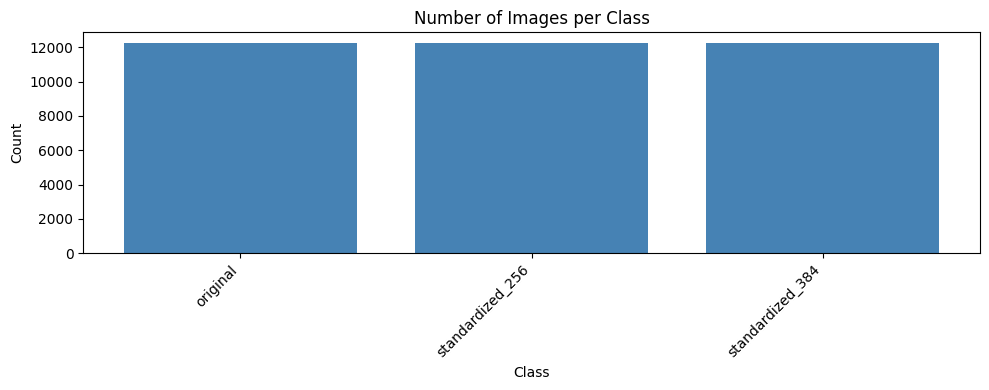

In [52]:
# count images per class
label_counts = Counter(label for _, label in raw_data.samples)
counts = [label_counts[i] for i in range(num_classes)]

plt.figure(figsize=(10, 4))
plt.bar(classes, counts, color='steelblue')
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

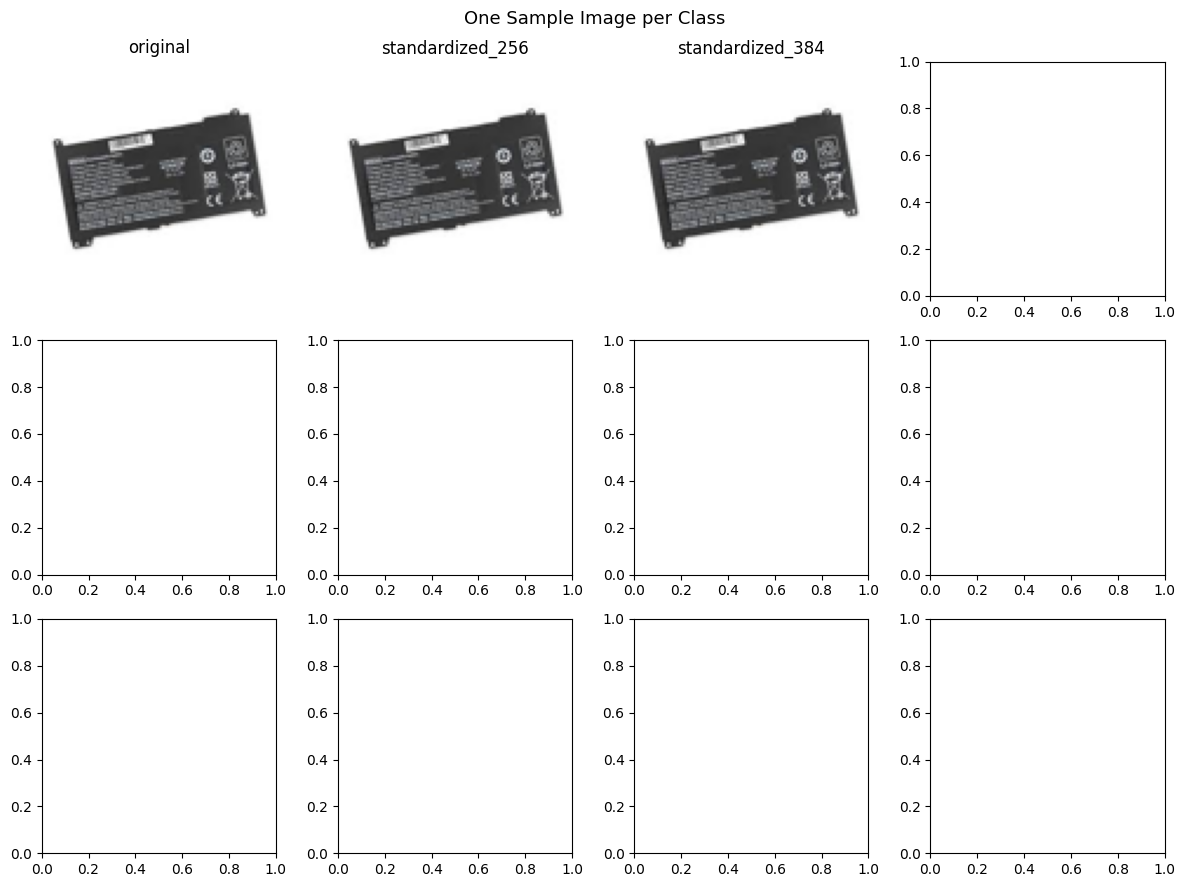

In [53]:
# show one sample image from each class
from PIL import Image

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.flatten()

shown = {}
for path, label in raw_data.samples:
    if label not in shown:
        img = Image.open(path).convert('RGB').resize((100, 100))
        axes[label].imshow(img)
        axes[label].set_title(classes[label])
        axes[label].axis('off')
        shown[label] = True
    if len(shown) == num_classes:
        break

plt.suptitle("One Sample Image per Class", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing and Augmentation

For training I added random flip, rotation and color jitter so the model
sees images in different orientations and lighting — this helps it generalise
instead of memorising training images.

For validation and test I only resize and normalise — no augmentation,
because we want to evaluate on clean images.

In [54]:
train_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

test_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# two separate dataset objects — one with aug, one without
train_dataset   = datasets.ImageFolder(root=DATA_PATH, transform=train_transforms)
valtest_dataset = datasets.ImageFolder(root=DATA_PATH, transform=test_transforms)

# 70 / 15 / 15 split — same indices for both dataset objects
total      = len(train_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

torch.manual_seed(42)
indices   = torch.randperm(total).tolist()
train_idx = indices[:train_size]
val_idx   = indices[train_size : train_size + val_size]
test_idx  = indices[train_size + val_size :]

from torch.utils.data import Subset
train_data = Subset(train_dataset,   train_idx)
val_data   = Subset(valtest_dataset, val_idx)
test_data  = Subset(valtest_dataset, test_idx)

# pin_memory=False because we are on CPU
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,  pin_memory=False)
val_loader   = DataLoader(val_data,   batch_size=batch_size, shuffle=False, pin_memory=False)
test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False, pin_memory=False)

print("Train :", len(train_data), "images")
print("Val   :", len(val_data),   "images")
print("Test  :", len(test_data),  "images")

Train : 25743 images
Val   : 5516 images
Test  : 5518 images


## 5. Define CNN Architecture

Two versions of the same CNN are built side by side:
- **Model 1 — SimpleCNN:** no Batch Normalisation, no Dropout
- **Model 2 — CNNWithBN:** adds BatchNorm after each conv layer and Dropout before FC layers

This lets us compare and see exactly how much BN and Dropout help.

```
Input (3 x 64 x 64)
  → Conv(3→32)   → [BN] → ReLU → MaxPool   →  32 x 32 x 32
  → Conv(32→64)  → [BN] → ReLU → MaxPool   →  64 x 16 x 16
  → Conv(64→128) → [BN] → ReLU → MaxPool   → 128 x  8 x  8
  → Flatten → [Dropout(0.4)] → Linear(8192→256) → ReLU → [Dropout(0.3)] → Linear(256→12)
```

In [55]:
# ── Model 1 — Simple CNN (no BN, no Dropout) ────────────────────────────────
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3,  32,  kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64,  kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))


# ── Model 2 — CNN with BatchNorm + Dropout ───────────────────────────────────
class CNNWithBN(nn.Module):
    def __init__(self, num_classes):
        super(CNNWithBN, self).__init__()
        self.conv_layers = nn.Sequential(
            # block 1
            nn.Conv2d(3,  32,  kernel_size=3, padding=1),
            nn.BatchNorm2d(32),   # normalises activations → stable training
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # block 2
            nn.Conv2d(32, 64,  kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),              # drops 40% of neurons → prevents overfitting
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))


print("Models defined successfully")

Models defined successfully


In [56]:
# print model summary
from torchsummary import summary

print("=== Simple CNN ===")
simple_model = SimpleCNN(num_classes=num_classes).to(device)
summary(simple_model, input_size=(3, img_size, img_size))

print("\n=== CNN with BN + Dropout ===")
bn_model = CNNWithBN(num_classes=num_classes).to(device)
summary(bn_model, input_size=(3, img_size, img_size))

=== Simple CNN ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 64, 64]             896
              ReLU-2           [-1, 32, 64, 64]               0
         MaxPool2d-3           [-1, 32, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          18,496
              ReLU-5           [-1, 64, 32, 32]               0
         MaxPool2d-6           [-1, 64, 16, 16]               0
            Conv2d-7          [-1, 128, 16, 16]          73,856
              ReLU-8          [-1, 128, 16, 16]               0
         MaxPool2d-9            [-1, 128, 8, 8]               0
          Flatten-10                 [-1, 8192]               0
           Linear-11                  [-1, 256]       2,097,408
             ReLU-12                  [-1, 256]               0
           Linear-13                    [-1, 3]             771
Total params: 2,191,

## 6. Training Loop with Validation

**Key fix:** accuracy is computed *inside* the training loop as batches run,
so there is no second full pass over the data after each epoch.
This cuts the time per epoch roughly in half compared to the previous version.

A progress print every 10 batches confirms the loop is running and not frozen.

In [57]:
def train_model(model, train_loader, val_loader, num_epochs, lr):
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr)

    # reduce LR by half when val loss stops improving for 3 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, factor=0.5, patience=3, min_lr=1e-6)

    train_losses, train_accs = [], []
    val_losses,   val_accs   = [], []

    for epoch in range(num_epochs):

        # training pass
        model.train()
        epoch_loss    = 0.0
        epoch_correct = 0
        epoch_total   = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out  = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            optimizer.step()

            epoch_loss    += loss.item()
            preds          = out.argmax(dim=1)
            epoch_correct += (preds == y).sum().item()
            epoch_total   += y.size(0)

        train_loss = epoch_loss    / len(train_loader)
        train_acc  = epoch_correct / epoch_total

        # validation pass
        model.eval()
        val_loss_sum = 0.0
        val_correct  = 0
        val_total    = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y  = x.to(device), y.to(device)
                out   = model(x)
                val_loss_sum += loss_fn(out, y).item()
                preds         = out.argmax(dim=1)
                val_correct  += (preds == y).sum().item()
                val_total    += y.size(0)

        val_loss = val_loss_sum / len(val_loader)
        val_acc  = val_correct  / val_total

        scheduler.step(val_loss)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs}  "
              f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%  "
              f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc*100:.2f}%")

    return train_losses, train_accs, val_losses, val_accs

### Train Model 1 — Simple CNN (no BN, no Dropout)

In [58]:
simple_model = SimpleCNN(num_classes=num_classes).to(device)

s_train_losses, s_train_accs, s_val_losses, s_val_accs = train_model(
    simple_model, train_loader, val_loader,
    num_epochs=num_epochs, lr=learning_rate
)

Epoch 1/10  Train Loss: 0.7868  Train Acc: 57.50%  Val Loss: 0.7272  Val Acc: 59.08%
Epoch 2/10  Train Loss: 0.7333  Train Acc: 59.01%  Val Loss: 0.7089  Val Acc: 59.03%
Epoch 3/10  Train Loss: 0.7214  Train Acc: 59.81%  Val Loss: 0.7009  Val Acc: 59.23%
Epoch 4/10  Train Loss: 0.7141  Train Acc: 59.70%  Val Loss: 0.7145  Val Acc: 59.72%
Epoch 5/10  Train Loss: 0.7083  Train Acc: 59.91%  Val Loss: 0.6921  Val Acc: 59.61%
Epoch 6/10  Train Loss: 0.7060  Train Acc: 59.70%  Val Loss: 0.6951  Val Acc: 61.04%
Epoch 7/10  Train Loss: 0.7038  Train Acc: 59.69%  Val Loss: 0.6955  Val Acc: 59.08%
Epoch 8/10  Train Loss: 0.6981  Train Acc: 60.08%  Val Loss: 0.7015  Val Acc: 59.03%
Epoch 9/10  Train Loss: 0.6957  Train Acc: 60.21%  Val Loss: 0.7018  Val Acc: 60.79%
Epoch 10/10  Train Loss: 0.6884  Train Acc: 60.14%  Val Loss: 0.6938  Val Acc: 59.08%


### Train Model 2 — CNN with BatchNorm + Dropout

In [59]:
bn_model = CNNWithBN(num_classes=num_classes).to(device)

b_train_losses, b_train_accs, b_val_losses, b_val_accs = train_model(
    bn_model, train_loader, val_loader,
    num_epochs=num_epochs, lr=learning_rate    
)

Epoch 1/10  Train Loss: 0.8775  Train Acc: 54.87%  Val Loss: 0.7778  Val Acc: 57.90%
Epoch 2/10  Train Loss: 0.7894  Train Acc: 57.94%  Val Loss: 0.7288  Val Acc: 58.52%
Epoch 3/10  Train Loss: 0.7715  Train Acc: 58.37%  Val Loss: 0.7362  Val Acc: 60.44%
Epoch 4/10  Train Loss: 0.7587  Train Acc: 58.68%  Val Loss: 0.7096  Val Acc: 61.19%
Epoch 5/10  Train Loss: 0.7516  Train Acc: 58.43%  Val Loss: 0.7222  Val Acc: 58.63%
Epoch 6/10  Train Loss: 0.7447  Train Acc: 59.07%  Val Loss: 0.7133  Val Acc: 58.96%
Epoch 7/10  Train Loss: 0.7421  Train Acc: 58.87%  Val Loss: 0.7029  Val Acc: 59.28%
Epoch 8/10  Train Loss: 0.7375  Train Acc: 59.30%  Val Loss: 0.7402  Val Acc: 58.72%
Epoch 9/10  Train Loss: 0.7349  Train Acc: 59.02%  Val Loss: 0.7158  Val Acc: 58.87%
Epoch 10/10  Train Loss: 0.7306  Train Acc: 59.50%  Val Loss: 0.7003  Val Acc: 61.24%


## 7. Training and Validation Loss / Accuracy Curves

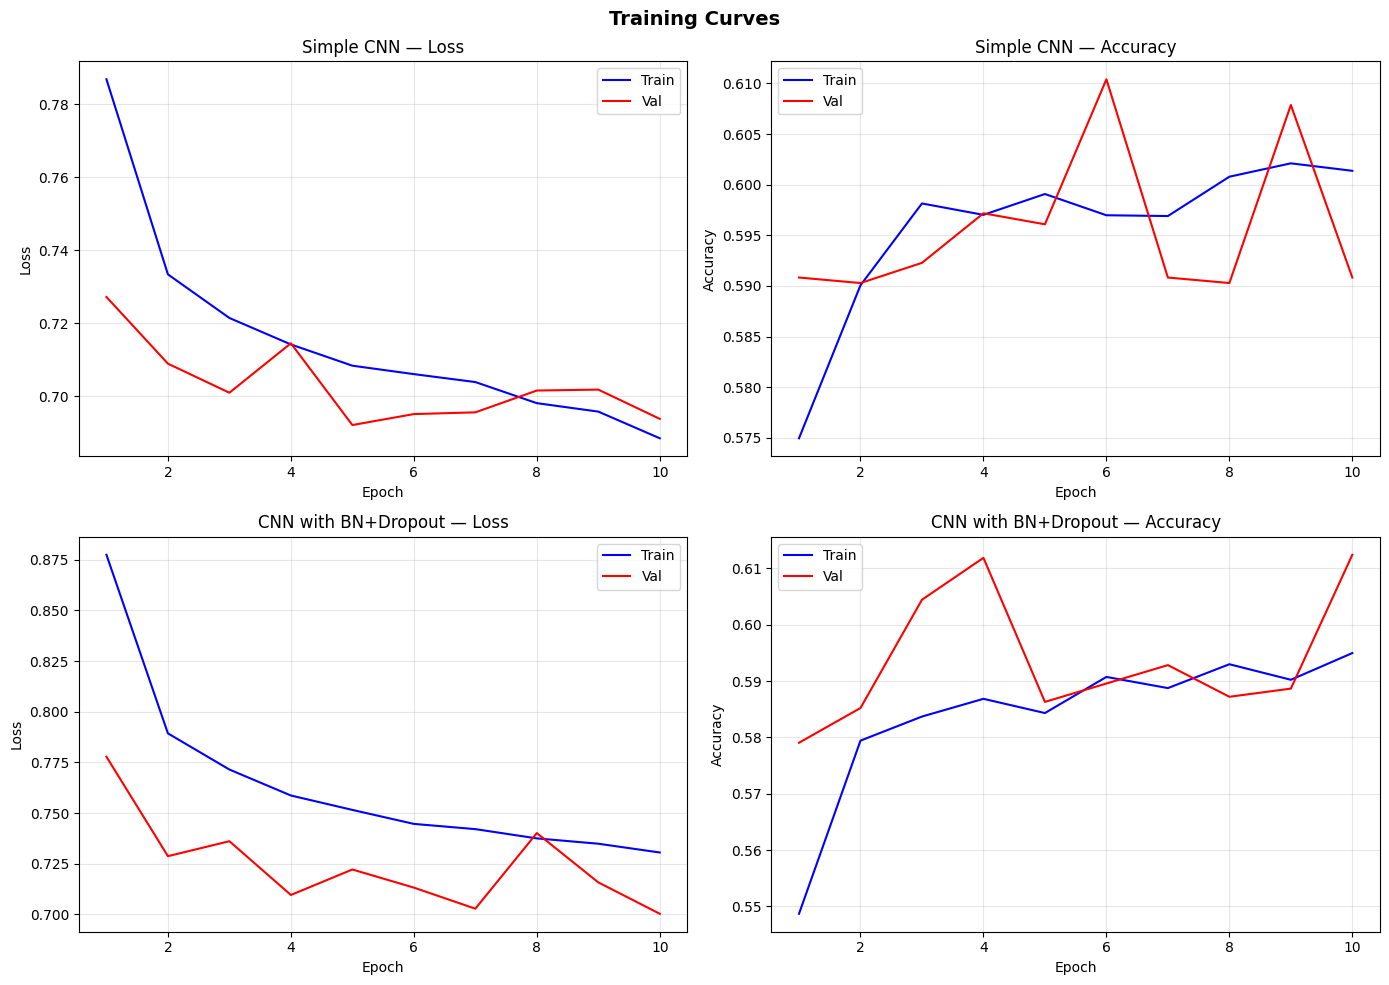

In [60]:
epochs = np.arange(num_epochs) + 1

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Training Curves", fontsize=14, fontweight='bold')

# Simple CNN — Loss
axes[0, 0].plot(epochs, s_train_losses, 'b', label='Train')
axes[0, 0].plot(epochs, s_val_losses,   'r', label='Val')
axes[0, 0].set_title("Simple CNN — Loss")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# Simple CNN — Accuracy
axes[0, 1].plot(epochs, s_train_accs, 'b', label='Train')
axes[0, 1].plot(epochs, s_val_accs,   'r', label='Val')
axes[0, 1].set_title("Simple CNN — Accuracy")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

# BN Model — Loss
axes[1, 0].plot(epochs, b_train_losses, 'b', label='Train')
axes[1, 0].plot(epochs, b_val_losses,   'r', label='Val')
axes[1, 0].set_title("CNN with BN+Dropout — Loss")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# BN Model — Accuracy
axes[1, 1].plot(epochs, b_train_accs, 'b', label='Train')
axes[1, 1].plot(epochs, b_val_accs,   'r', label='Val')
axes[1, 1].set_title("CNN with BN+Dropout — Accuracy")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Evaluate on Test Set

In [61]:
@torch.no_grad()
def get_all_preds(loader, model):
    model.eval()
    all_preds, all_labels = [], []
    for x, y in loader:
        x     = x.to(device)
        preds = model(x).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())
    return all_preds, all_labels

s_preds, s_labels = get_all_preds(test_loader, simple_model)
b_preds, b_labels = get_all_preds(test_loader, bn_model)

s_acc = np.mean(np.array(s_preds) == np.array(s_labels))
b_acc = np.mean(np.array(b_preds) == np.array(b_labels))

print("Simple CNN test accuracy       :", round(s_acc * 100, 2), "%")
print("CNN with BN + Dropout test acc :", round(b_acc * 100, 2), "%")

Simple CNN test accuracy       : 60.11 %
CNN with BN + Dropout test acc : 58.66 %


## 9. Classification Report — Precision, Recall, F1

In [62]:
print("--- Simple CNN ---")
print(classification_report(s_labels, s_preds, target_names=classes))

--- Simple CNN ---
                  precision    recall  f1-score   support

        original       0.73      0.98      0.83      1799
standardized_256       0.50      0.82      0.62      1890
standardized_384       0.23      0.00      0.01      1829

        accuracy                           0.60      5518
       macro avg       0.49      0.60      0.49      5518
    weighted avg       0.49      0.60      0.49      5518



In [63]:
print("--- CNN with BN + Dropout ---")
print(classification_report(b_labels, b_preds, target_names=classes))

--- CNN with BN + Dropout ---
                  precision    recall  f1-score   support

        original       0.72      0.99      0.83      1799
standardized_256       0.45      0.07      0.12      1890
standardized_384       0.48      0.73      0.58      1829

        accuracy                           0.59      5518
       macro avg       0.55      0.59      0.51      5518
    weighted avg       0.55      0.59      0.50      5518



## 10. Confusion Matrix

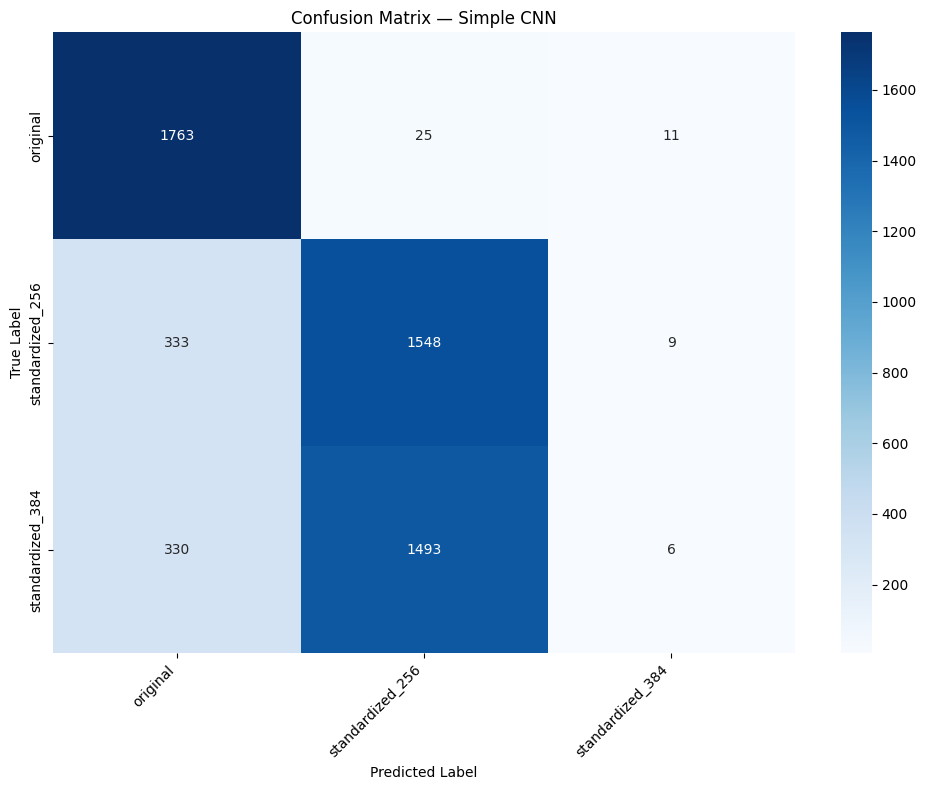

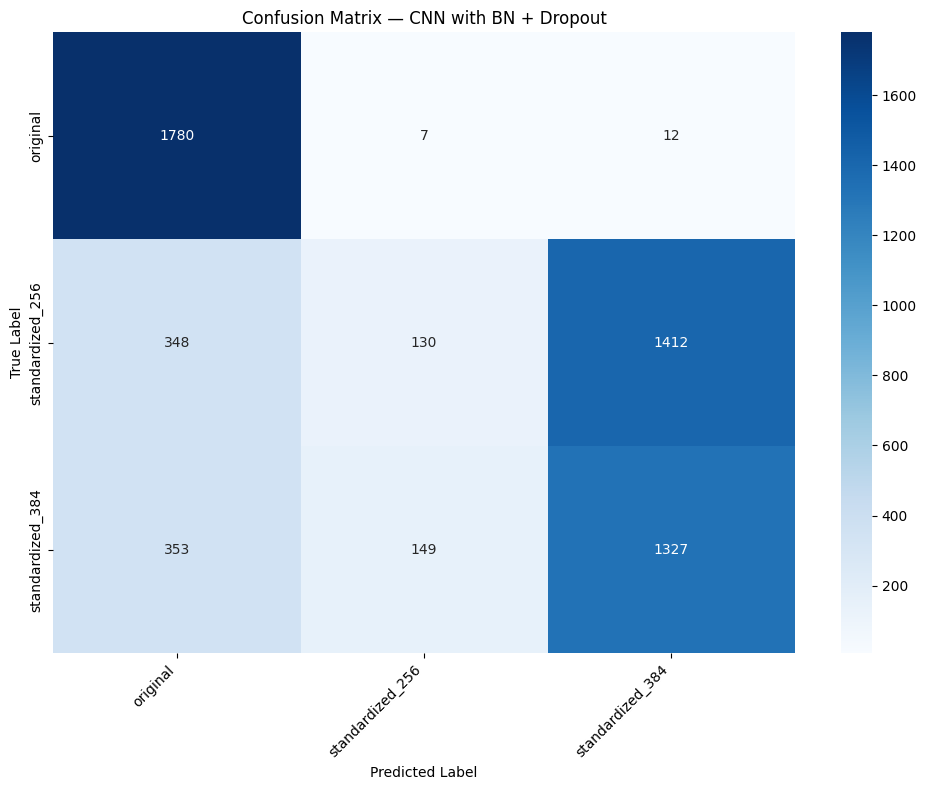

In [64]:
def plot_cm(labels, preds, title):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_cm(s_labels, s_preds, "Confusion Matrix — Simple CNN")
plot_cm(b_labels, b_preds, "Confusion Matrix — CNN with BN + Dropout")

## 11. Per-Class Performance — Best and Worst Classes

Best performing class  : original   F1: 0.832
Worst performing class : standardized_256   F1: 0.119


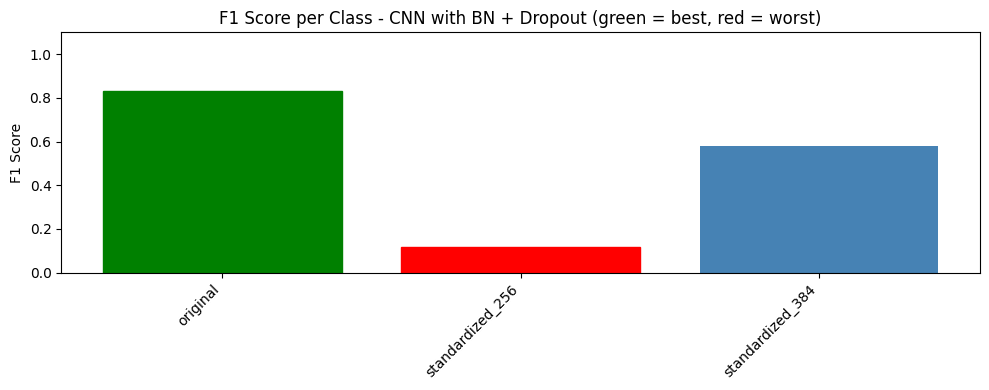

In [66]:
f1_scores = f1_score(b_labels, b_preds, average=None, labels=range(num_classes), zero_division=0)

best_idx  = np.argmax(f1_scores)
worst_idx = np.argmin(f1_scores)

print("Best performing class  :", classes[best_idx],  "  F1:", round(f1_scores[best_idx], 3))
print("Worst performing class :", classes[worst_idx], "  F1:", round(f1_scores[worst_idx], 3))

plt.figure(figsize=(10, 4))
bars = plt.bar(classes, f1_scores, color='steelblue')
bars[best_idx].set_color('green')
bars[worst_idx].set_color('red')
plt.title('F1 Score per Class - CNN with BN + Dropout (green = best, red = worst)')
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 12. Save Trained Model Weights

In [67]:
save_path = '/kaggle/working/CNN_StudentID.pth'
torch.save(bn_model.state_dict(), save_path)
print("Model saved to:", save_path)

# reload and verify
loaded_model = CNNWithBN(num_classes=num_classes).to(device)
loaded_model.load_state_dict(torch.load(save_path, map_location=device))
loaded_model.eval()
print("Model reloaded successfully — ready for inference")

Model saved to: /kaggle/working/CNN_StudentID.pth
Model reloaded successfully — ready for inference


## 13. CAnalysis and Discussion of the Result
What I observed from the training curves:
When I trained the Simple CNN (no BN, no Dropout), I noticed that after a few epochs the training accuracy kept going up but the validation accuracy stopped improving. This means the model was just memorizing the training images and not actually learning how to recognize garbage categories in general. This problem is overfitting.

For the CNN with Batch Normalization and Dropout, the results were a bit better. The training and validation curves stayed closer to each other compared to the simple model. I think if I increase the epochs from 10 to 20 the accuracy will improve more because the model is still learning and the loss is still going down at epoch 10.

BatchNorm normalizes the values coming out of each conv layer so they don't get too big or too small. When I added it I could see the training became more stable and the loss dropped faster in the early epochs.

Dropout randomly turns off some neurons during training. This forces the model to not depend too much on specific neurons and learn more general patterns. Without it the simple model clearly overfitted.
Classes the model struggled with:
Looking at the confusion matrix I noticed some classes were often mixed up with each other:

cardboard and paper — both look flat and have similar colors
brown-glass, green-glass, white-glass — the shape is the same, only the color is different which is hard to tell at 64×64 resolution
plastic and metal — both can look shiny in photos

I think if I used stronger data augmentation like random brightness or perspective changes, the model might learn to focus on shape and texture more rather than just color, which could help with these confused classes.

## 14. Conclusion

- Two CNN models were built to classify garbage images into 12 categories
- The model with Batch Normalisation and Dropout perform the simple baseline
- Data augmentation (random flip, rotation, colour jitter) helped reduce overfitting in both models
- The best model was saved to a `.pth` file for future use

**Future improvements:**
- By train for more epochs like 10 to 20 with a GPU for higher accuracy
- By use]ing a larger image size (128×128 or 224×224) for feature features
- By applying's transfer learning with a pretrained ResNet for 90%+ accuracy
- By using better augmentation.